# Exploratory Data Analysis: Class Balance and Predictor Distributions

This notebook visualises the failure target and key environmental, operational, thermal, vibration, and lubrication predictors. Figures are saved to `outputs/figures/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid', context='notebook')
ROOT = Path.cwd().parent
if not (ROOT / 'data' / 'raw' / 'wind_turbine_detection.csv').exists():
    ROOT = Path.cwd() / 'PROJECT 1'
DATA_PATH = ROOT / 'data' / 'raw' / 'wind_turbine_detection.csv'
FIGURES_DIR = ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(DATA_PATH)

display(Markdown(f'Loaded **{df.shape[0]:,} records** from `{DATA_PATH.name}`. Figures will be saved to `{FIGURES_DIR}`.'))

Matplotlib is building the font cache; this may take a moment.


Loaded **131,760 records** from `wind_turbine_detection.csv`. Figures will be saved to `/Users/sanniadedokun/Desktop/DBA/PROJECT 1/outputs/figures`.

## Target class balance

,count,percentage
failure,,
Normal (0),127807,96.999848
Fault (1),3953,3.000152


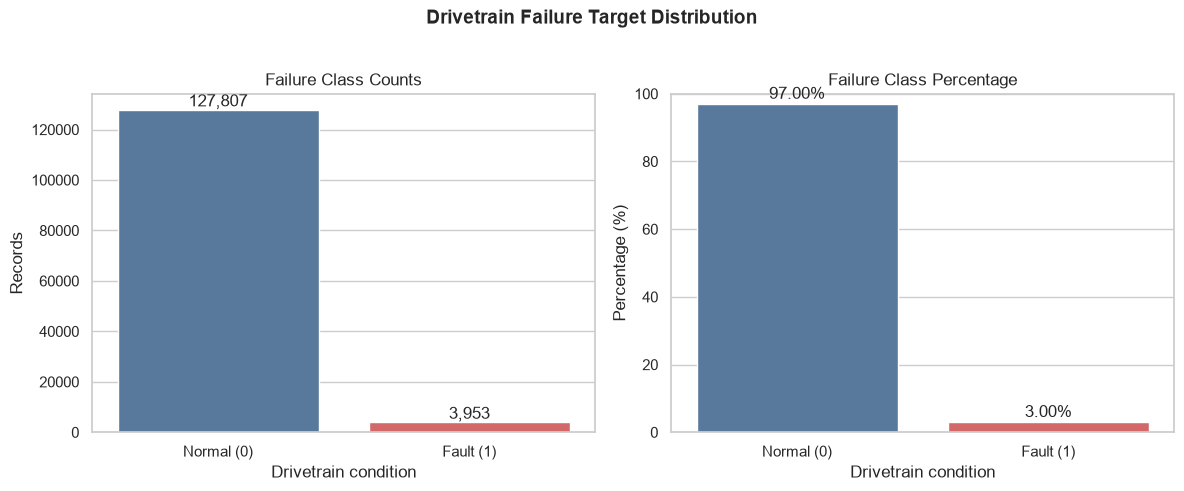

Saved: /Users/sanniadedokun/Desktop/DBA/PROJECT 1/outputs/figures/class_balance.png


In [2]:
# Target class balance: counts and percentages
class_balance = (
    df['failure'].value_counts().sort_index().rename(index={0: 'Normal (0)', 1: 'Fault (1)'})
    .rename('count').to_frame()
)
class_balance['percentage'] = class_balance['count'] / class_balance['count'].sum() * 100
display(Markdown('## Target class balance'))
display(class_balance)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
palette = ['#4C78A8', '#E45756']
sns.barplot(data=class_balance.reset_index(), x='failure', y='count', hue='failure', palette=palette, legend=False, ax=axes[0])
axes[0].set(title='Failure Class Counts', xlabel='Drivetrain condition', ylabel='Records')
for index, row in class_balance.reset_index().iterrows():
    axes[0].text(index, row['count'], f"{row['count']:,}", ha='center', va='bottom')

sns.barplot(data=class_balance.reset_index(), x='failure', y='percentage', hue='failure', palette=palette, legend=False, ax=axes[1])
axes[1].set(title='Failure Class Percentage', xlabel='Drivetrain condition', ylabel='Percentage (%)', ylim=(0, 100))
for index, row in class_balance.reset_index().iterrows():
    axes[1].text(index, row['percentage'] + 1.5, f"{row['percentage']:.2f}%", ha='center')

fig.suptitle('Drivetrain Failure Target Distribution', y=1.02, fontsize=14, fontweight='bold')
fig.tight_layout()
class_balance_path = FIGURES_DIR / 'class_balance.png'
fig.savefig(class_balance_path, dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved: {class_balance_path}')

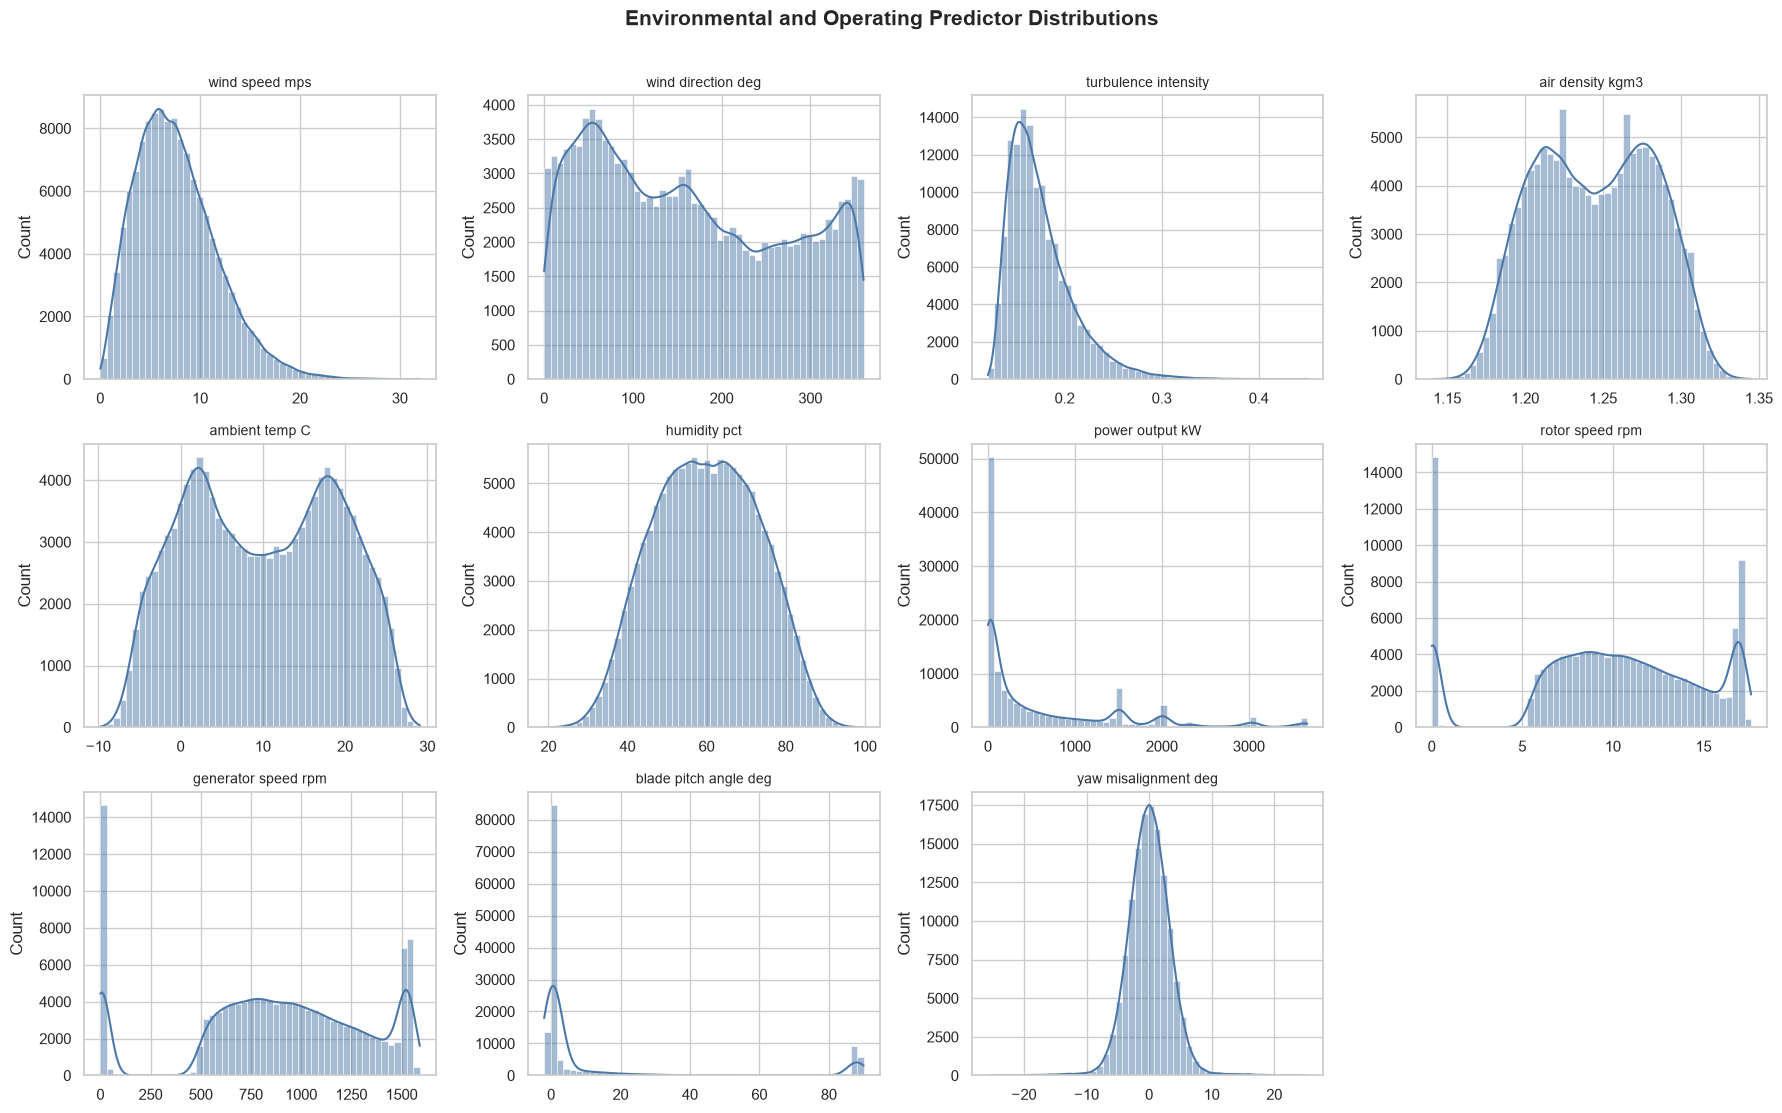

Saved: /Users/sanniadedokun/Desktop/DBA/PROJECT 1/outputs/figures/environmental_operational_distributions.png


In [3]:
# Environmental and operating predictors
environmental_operational = [
    'wind_speed_mps', 'wind_direction_deg', 'turbulence_intensity', 'air_density_kgm3',
    'ambient_temp_C', 'humidity_pct', 'power_output_kW', 'rotor_speed_rpm',
    'generator_speed_rpm', 'blade_pitch_angle_deg', 'yaw_misalignment_deg'
]

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
for axis, column in zip(axes.flat, environmental_operational):
    sns.histplot(data=df, x=column, bins=50, kde=True, color='#4C78A8', ax=axis)
    axis.set_title(column.replace('_', ' '), fontsize=10)
    axis.set_xlabel('')
for axis in axes.flat[len(environmental_operational):]:
    axis.set_visible(False)
fig.suptitle('Environmental and Operating Predictor Distributions', y=1.01, fontsize=15, fontweight='bold')
fig.tight_layout()
environment_path = FIGURES_DIR / 'environmental_operational_distributions.png'
fig.savefig(environment_path, dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved: {environment_path}')

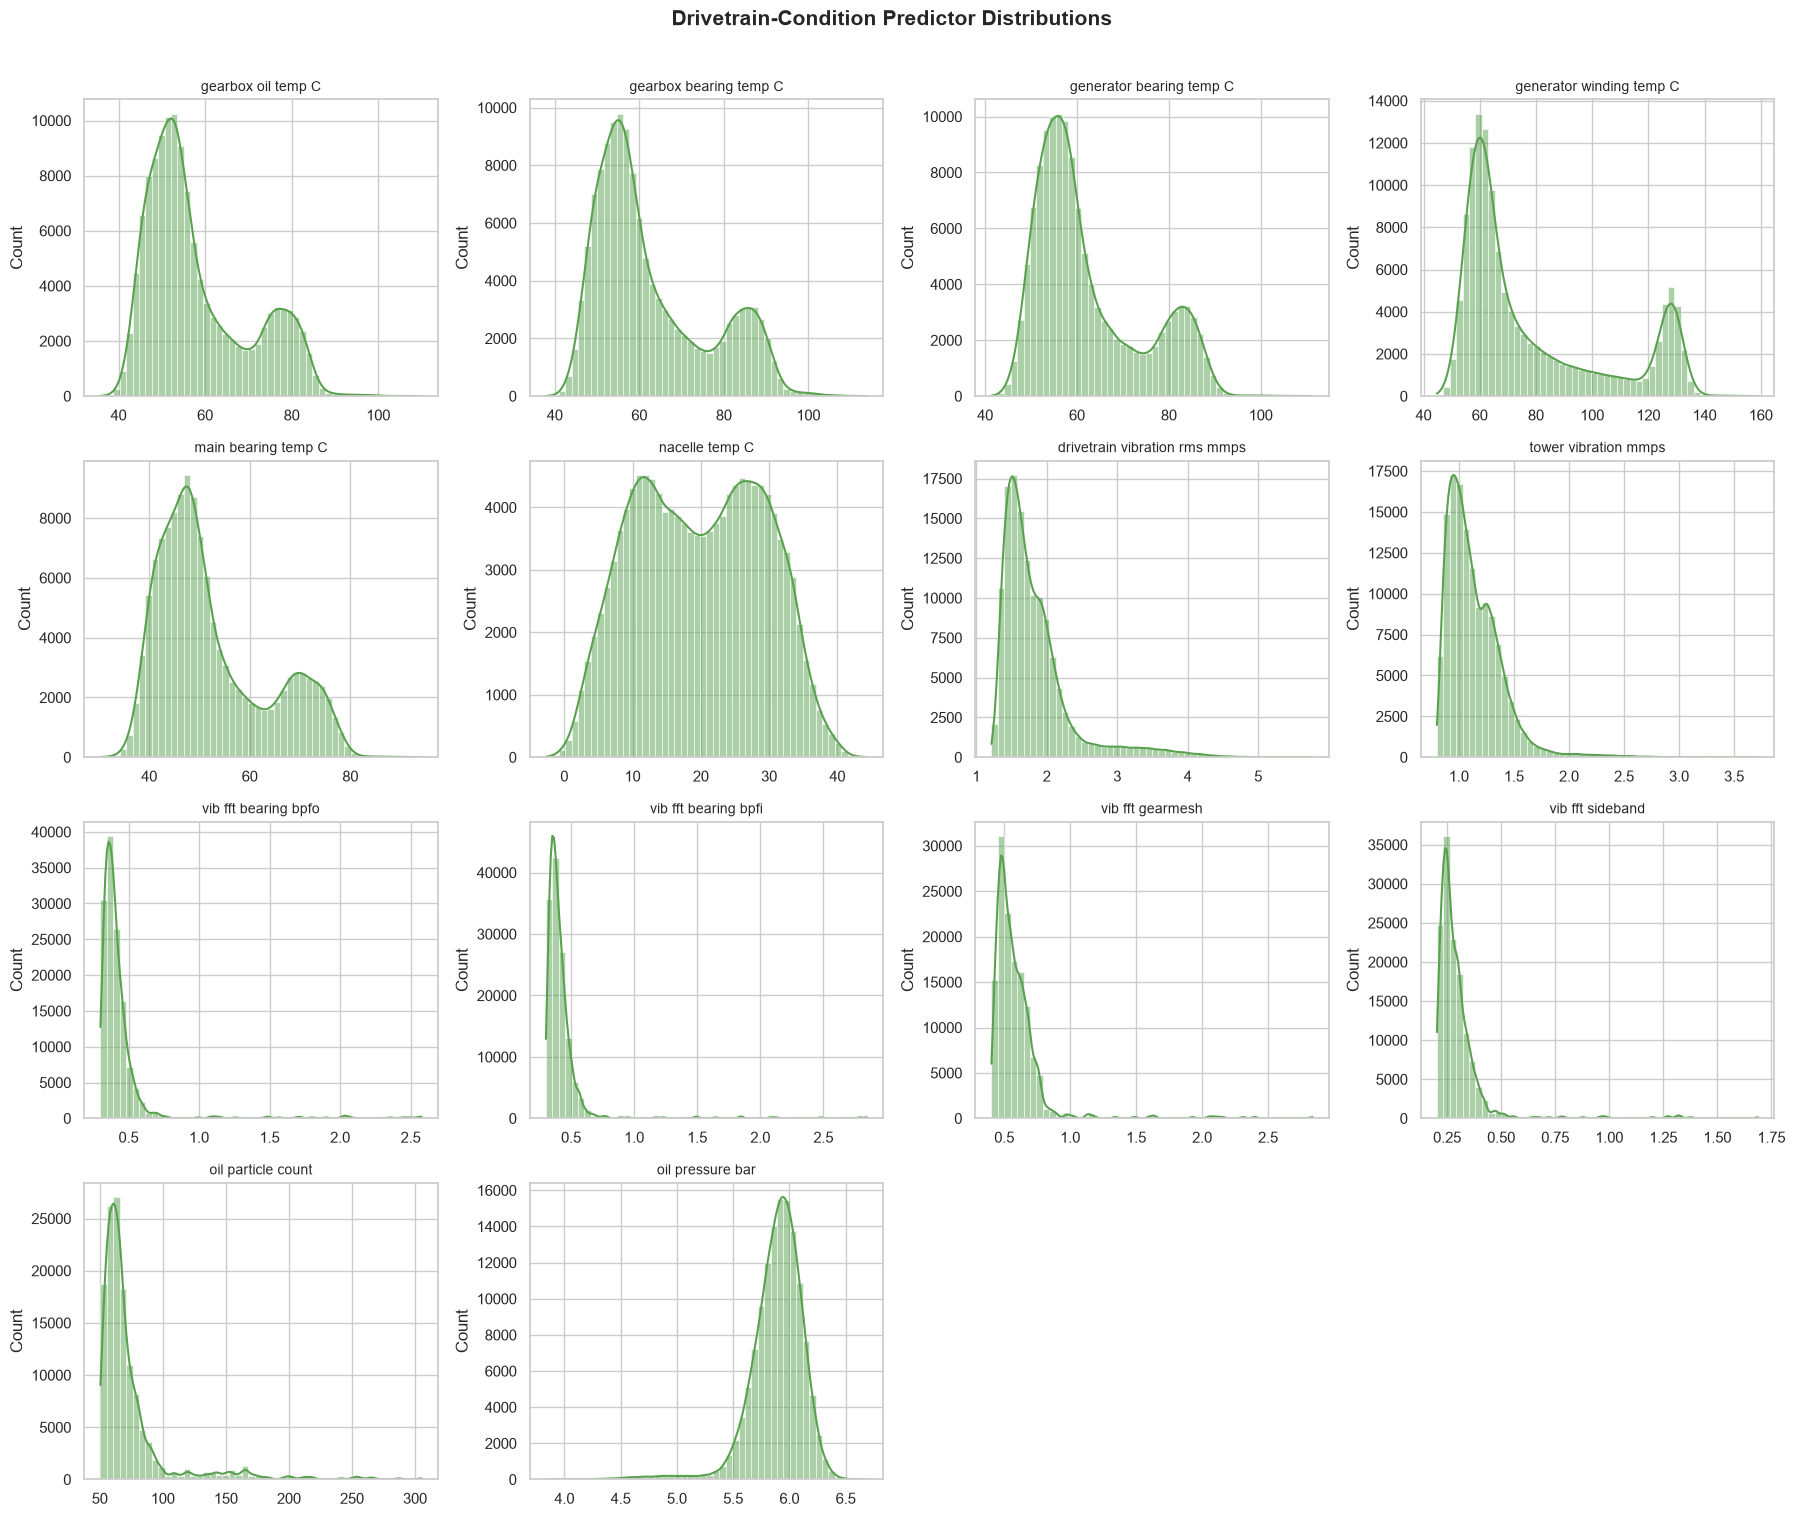

Saved: /Users/sanniadedokun/Desktop/DBA/PROJECT 1/outputs/figures/drivetrain_sensor_distributions.png


In [4]:
# Drivetrain-condition predictors: temperature, vibration/frequency, and lubrication
drivetrain_predictors = [
    'gearbox_oil_temp_C', 'gearbox_bearing_temp_C', 'generator_bearing_temp_C',
    'generator_winding_temp_C', 'main_bearing_temp_C', 'nacelle_temp_C',
    'drivetrain_vibration_rms_mmps', 'tower_vibration_mmps',
    'vib_fft_bearing_bpfo', 'vib_fft_bearing_bpfi', 'vib_fft_gearmesh',
    'vib_fft_sideband', 'oil_particle_count', 'oil_pressure_bar'
]

fig, axes = plt.subplots(4, 4, figsize=(18, 15))
for axis, column in zip(axes.flat, drivetrain_predictors):
    sns.histplot(data=df, x=column, bins=50, kde=True, color='#59A14F', ax=axis)
    axis.set_title(column.replace('_', ' '), fontsize=10)
    axis.set_xlabel('')
for axis in axes.flat[len(drivetrain_predictors):]:
    axis.set_visible(False)
fig.suptitle('Drivetrain-Condition Predictor Distributions', y=1.01, fontsize=15, fontweight='bold')
fig.tight_layout()
drivetrain_path = FIGURES_DIR / 'drivetrain_sensor_distributions.png'
fig.savefig(drivetrain_path, dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved: {drivetrain_path}')